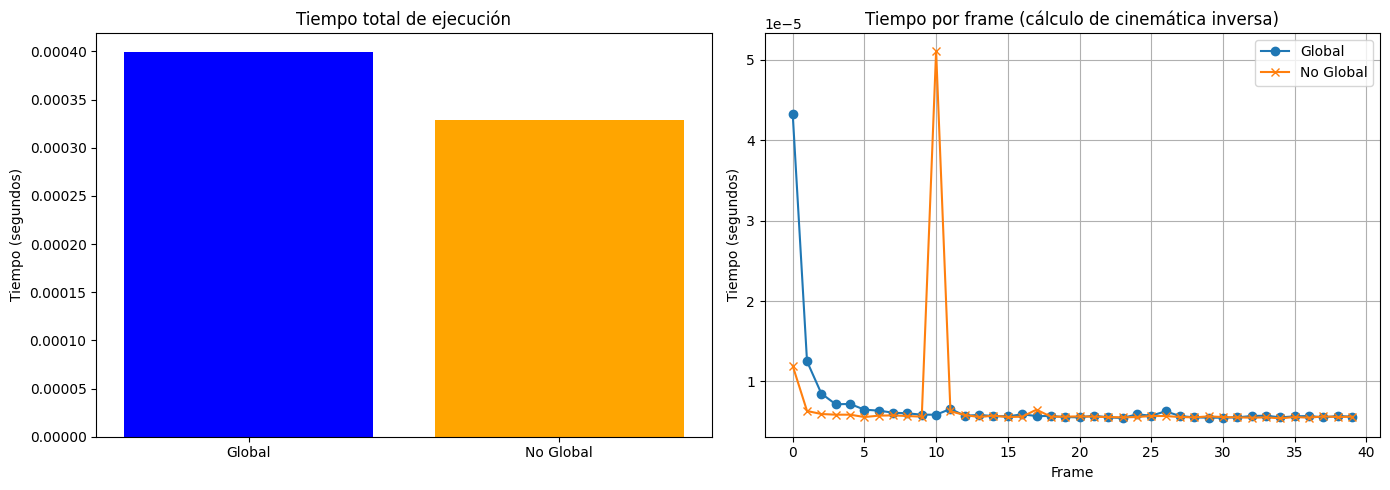

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import time

# Parámetros
L1, L2 = 1.0, 1.0
T = 40
x_ini, x_fin = -1.5, 1.5
y_ini = y_fin = 1.2
a = 2
x0 = 0.0

x_deseado = np.linspace(x_ini, x_fin, T)
y_deseado = a * (np.cosh((x_deseado - x0) / a) - np.cosh((x_ini - x0) / a)) + 1.2

# Funciones cinemáticas
def forward_kinematics(theta1, theta2):
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)
    return (x1, y1), (x2, y2)

def inverse_kinematics(x, y, change_codo=False):
    r = np.sqrt(x**2 + y**2)
    cos_theta2 = (r**2 - L1**2 - L2**2) / (2 * L1 * L2)
    theta2 = np.arccos(np.clip(cos_theta2, -1, 1))
    if not change_codo:
        theta2 = -theta2
    theta1 = np.arctan2(y, x) - np.arctan2(L2 * np.sin(theta2), L1 + L2 * np.cos(theta2))
    return theta1, theta2

# MÉTODO GLOBAL
start_global = time.perf_counter()
theta1_opt, theta2_opt = [], []
tiempos_global = []

for i in range(T):
    t0 = time.perf_counter()
    change_codo = i > T // 2
    theta1, theta2 = inverse_kinematics(x_deseado[i], y_deseado[i], change_codo)
    theta1_opt.append(theta1)
    theta2_opt.append(theta2)
    tiempos_global.append(time.perf_counter() - t0)

total_global = time.perf_counter() - start_global

# MÉTODO NO GLOBAL (solo tiempos)
tiempos_local = []
start_local = time.perf_counter()
for i in range(T):
    t0 = time.perf_counter()
    change_codo = i > T // 2
    inverse_kinematics(x_deseado[i], y_deseado[i], change_codo)
    tiempos_local.append(time.perf_counter() - t0)
total_local = time.perf_counter() - start_local

# GRAFICAR COMPARACIÓN DE EFICIENCIA
plt.figure(figsize=(14, 5))

# Tiempo total
plt.subplot(1, 2, 1)
plt.bar(["Global", "No Global"], [total_global, total_local], color=["blue", "orange"])
plt.title("Tiempo total de ejecución")
plt.ylabel("Tiempo (segundos)")

# Tiempos por frame
plt.subplot(1, 2, 2)
plt.plot(tiempos_global, label="Global", marker='o')
plt.plot(tiempos_local, label="No Global", marker='x')
plt.title("Tiempo por frame (cálculo de cinemática inversa)")
plt.xlabel("Frame")
plt.ylabel("Tiempo (segundos)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
